✅ Dataset Loaded Successfully
Shape: (5000, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0        2      0   
1   37    1   2       130   250    0        1      187      0        4      0   
2   41    0   1       130   204    0        0      172      0        1      2   
3   56    1   1       120   236    0        1      178      0        1      2   
4   57    0   0       120   354    0        1      163      1        1      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

========== T-TEST RESULTS ==========

Feature: chol
T-statistic: -6.5559
P-value: 0.0
✅ Significant difference found

Feature: trestbps
T-statistic: -9.5654
P-value: 0.0
✅ Significant difference found

Feature: thalach
T-statistic: 31.7086
P-value: 0.0
✅ Significant difference found

Feature: oldpeak
T-statistic: -32.9295
P-value:

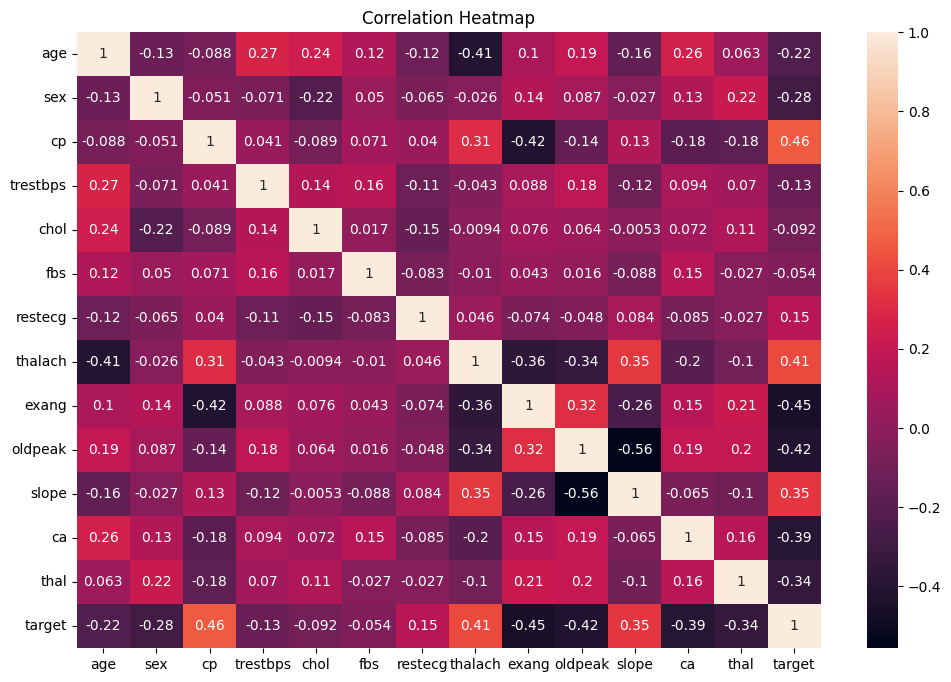

In [1]:
import pandas as pd
from scipy.stats import ttest_ind, chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# Load processed dataset
df = pd.read_csv(r"D:\Project\Heart_disease\HeartDisease_Project\data\processed_data.csv")

print("✅ Dataset Loaded Successfully")
print("Shape:", df.shape)
print(df.head())

# -------------------------------
# 1) T-TEST FOR MULTIPLE NUMERIC FEATURES
# -------------------------------
numeric_features = ["chol", "trestbps", "thalach", "oldpeak"]

print("\n========== T-TEST RESULTS ==========")

for feature in numeric_features:
    group1 = df[df["target"] == 1][feature].dropna()
    group2 = df[df["target"] == 0][feature].dropna()

    t_stat, p_value = ttest_ind(group1, group2)

    print(f"\nFeature: {feature}")
    print("T-statistic:", round(t_stat, 4))
    print("P-value:", round(p_value, 6))

    if p_value < 0.05:
        print("✅ Significant difference found")
    else:
        print("❌ No significant difference")

# -------------------------------
# 2) CHI-SQUARE TEST FOR CATEGORICAL FEATURE
# -------------------------------
print("\n========== CHI-SQUARE TEST ==========")

contingency_table = pd.crosstab(df["cp"], df["target"])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", round(chi2, 4))
print("P-value:", round(p, 6))

if p < 0.05:
    print("✅ Chest pain type (cp) is significantly associated with heart disease")
else:
    print("❌ No strong association found")

# -------------------------------
# 3) CORRELATION WITH TARGET
# -------------------------------
print("\n========== CORRELATION WITH TARGET ==========")

correlation = df.corr()["target"].sort_values(ascending=False)
print(correlation)

# Heatmap for report
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()